SWASTHIKA M 24BAD121
Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


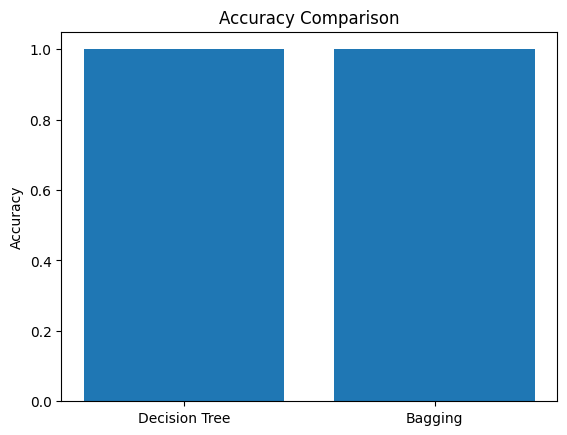

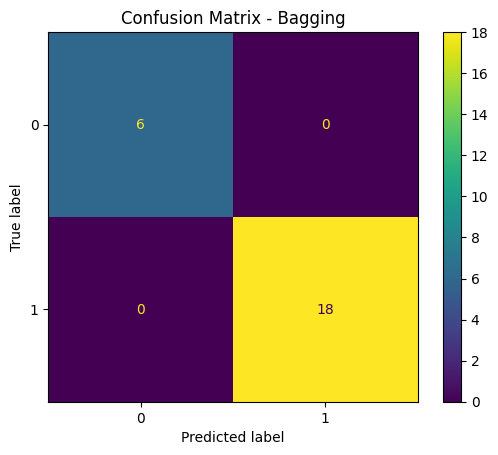

In [3]:

#Ensemble Techniques - Bagging
print("SWASTHIKA M 24BAD121")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load Dataset
data = pd.read_csv("diabetes_bagging.csv")

# Split Features and Target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Decision Tree Model

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)


# Bagging Classifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)
# Accuracy Comparison

print("Decision Tree Accuracy:", dt_accuracy)
print("Bagging Accuracy:", bag_accuracy)

# Bar Graph
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
# Confusion Matrix (Bagging)
cm = confusion_matrix(y_test, y_pred_bag)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Bagging")
plt.show()

SWASTHIKA M 24BAD121
AdaBoost Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


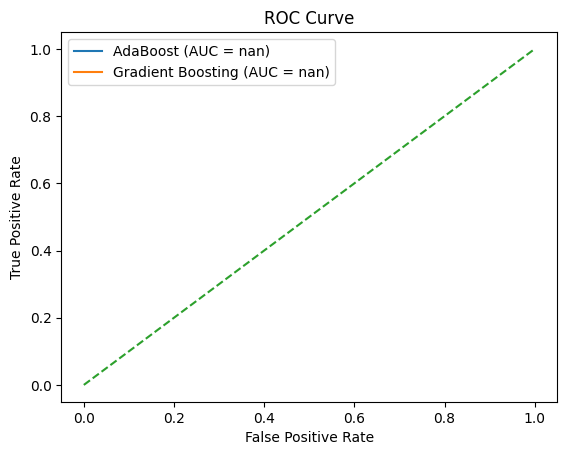

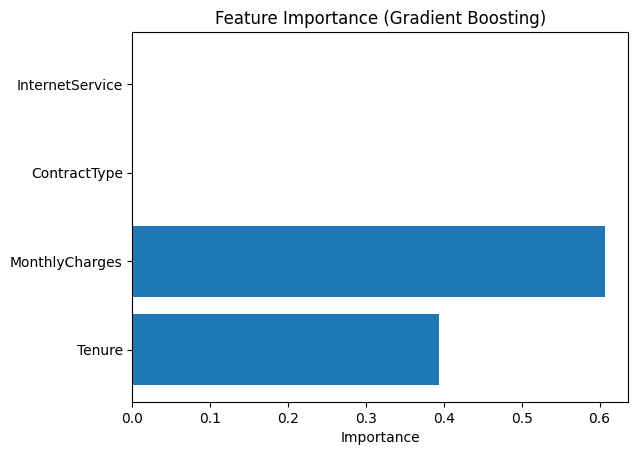

In [4]:

#  Boosting
print("SWASTHIKA M 24BAD121")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

# Load Dataset
data = pd.read_csv("churn_boosting.csv")

# Convert categorical columns to numeric
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Features & Target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#  AdaBoost Model

ada_model = AdaBoostClassifier(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)
# Gradient Boosting Model

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)
# Accuracy Comparison

print("AdaBoost Accuracy:", ada_acc)
print("Gradient Boosting Accuracy:", gb_acc)
# ROC Curve

y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
# Feature Importance

importance = gb_model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance")
plt.show()

SWASTHIKA M 24BAD121
Accuracies: {10: 1.0, 50: 1.0, 100: 1.0, 150: 1.0, 200: 1.0}


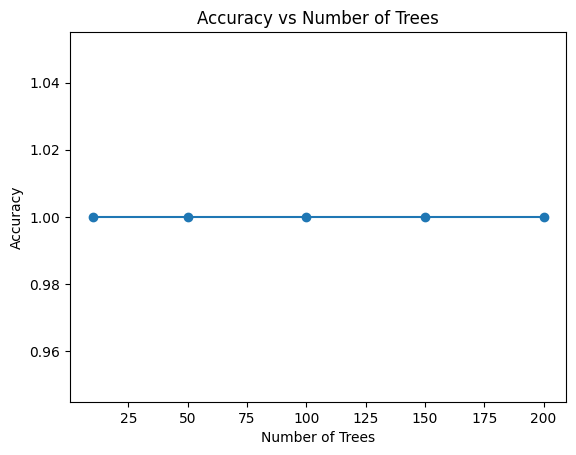

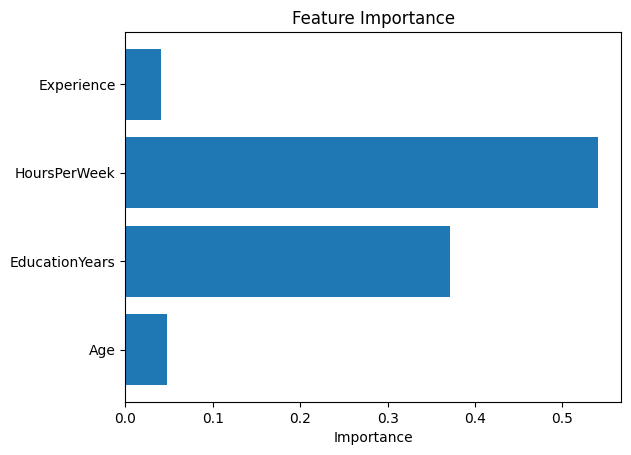

In [5]:
print("SWASTHIKA M 24BAD121")
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("income_random_forest.csv")

le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

X = data.drop("Income", axis=1)
y = data["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

trees = [10, 50, 100, 150, 200]
accuracies = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print("Accuracies:", dict(zip(trees, accuracies)))

plt.plot(trees, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

importance = final_model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

SWASTHIKA M 24BAD121
Logistic Regression: 0.8333333333333334
SVM: 0.8333333333333334
Decision Tree: 0.9583333333333334
Stacking: 0.9583333333333334


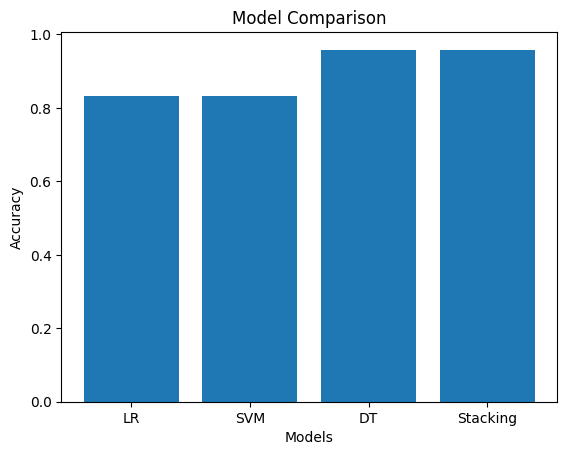

In [13]:
print("SWASTHIKA M 24BAD121")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("heart_stacking.csv")

# Encode categorical columns
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Automatically pick last column as target (NO ERROR)
target_col = data.columns[-1]

X = data.drop(target_col, axis=1)
y = data[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Base models
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

# Train base models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_dt = dt.predict(X_test)

# Accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Stacking
estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, y_pred_stack)
print("Logistic Regression:", acc_lr)
print("SVM:", acc_svm)
print("Decision Tree:", acc_dt)
print("Stacking:", acc_stack)

# Graph
models = ["LR", "SVM", "DT", "Stacking"]
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

SWASTHIKA M 24BAD121
Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


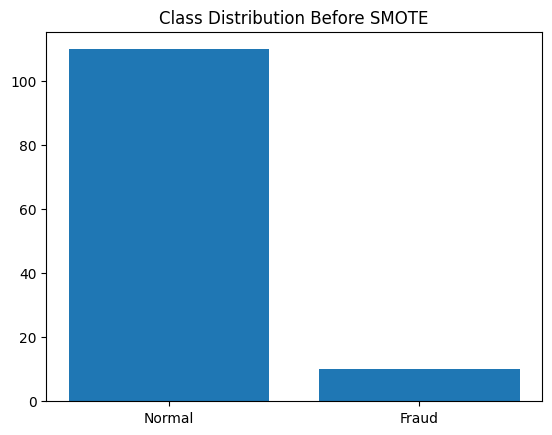

Before SMOTE:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24

After SMOTE:
 Fraud
0    88
1    88
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


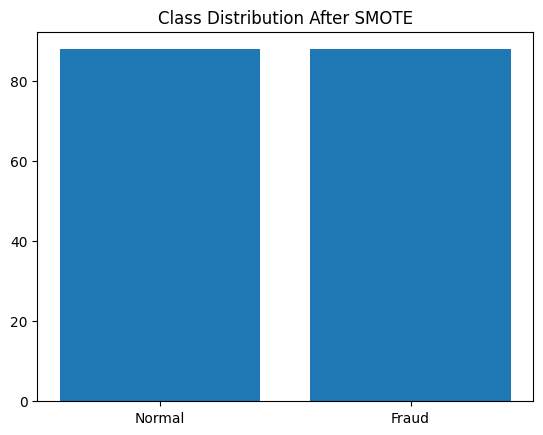

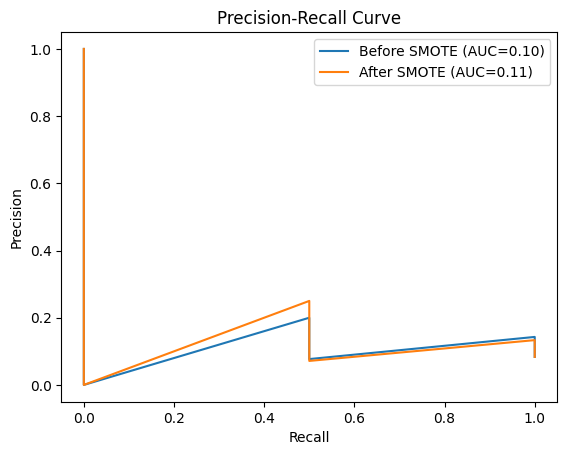

In [8]:
print("SWASTHIKA M 24BAD121")
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

data = pd.read_csv("fraud_smote.csv")

X = data.drop("Fraud", axis=1)
y = data["Fraud"]

print("Before SMOTE:\n", y.value_counts())

plt.bar(["Normal", "Fraud"], y.value_counts())
plt.title("Class Distribution Before SMOTE")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_before = LogisticRegression(max_iter=1000)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)
print("Before SMOTE:\n", classification_report(y_test, y_pred_before))

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

plt.bar(["Normal", "Fraud"], pd.Series(y_train_sm).value_counts())
plt.title("Class Distribution After SMOTE")
plt.show()

model_after = LogisticRegression(max_iter=1000)
model_after.fit(X_train_sm, y_train_sm)

y_prob_before = model_before.predict_proba(X_test)[:, 1]
y_prob_after = model_after.predict_proba(X_test)[:, 1]

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

auc_b = auc(recall_b, precision_b)
auc_a = auc(recall_a, precision_a)

plt.plot(recall_b, precision_b, label=f"Before SMOTE (AUC={auc_b:.2f})")
plt.plot(recall_a, precision_a, label=f"After SMOTE (AUC={auc_a:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()